<a href="https://colab.research.google.com/github/putrileonita523/UTS_BIG_DATA_HANI_NURAINI/blob/main/UTS_BIG_DATA_HANI_NURAINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [4]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [6]:
import pandas as pd

# baca file csv
df = pd.read_csv('ulasan_google_play.csv')

# fungsi sentiment sederhana
def sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

# buat kolom sentimen
df['Sentimen'] = df['score'].apply(sentiment)

# hitung jumlah sentimen
hasil = df['Sentimen'].value_counts()

print(hasil)


Sentimen
Positif    67
Negatif    29
Netral      4
Name: count, dtype: int64


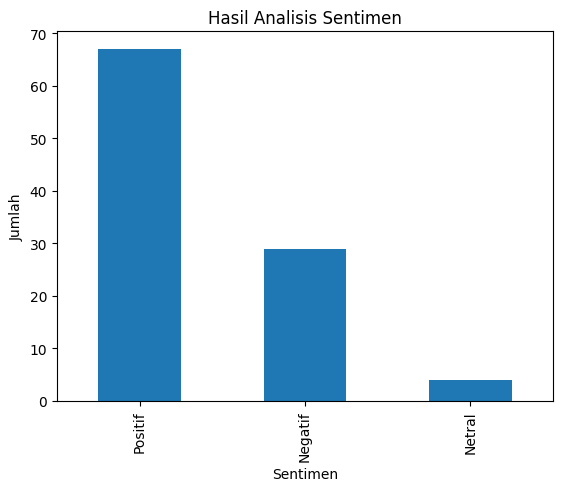

In [7]:
import matplotlib.pyplot as plt

# grafik batang
hasil.plot(kind='bar')

plt.title('Hasil Analisis Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

plt.show()